In [ ]:
# %pip install seaborn matplotlib

     ---------------------------------------- 0.0/294.9 kB ? eta -:--:--
     -------------------------------------- 294.9/294.9 kB 9.2 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 25.0.1
[notice] To update, run: C:\Users\Suoxrt\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
ruta = Path('..') / '..' / 'Fuentes/Studio_Ghibli.csv'
with open(ruta, 'r', encoding='utf-8') as f:
    df = pd.read_csv(f)

# Recaudación de salida adquirida por género  

In [13]:
# Lista de generos:
generos1 = df['Genre 1'].unique()
generos2 = df['Genre 2'].unique()
generos3 = df['Genre 3'].unique()

# Unimos las listas de generos en una sola lista
generos = list(set(generos1) | set(generos2) | set(generos3))
#generos.remove('nan')
generos.remove('Animation')
generos_limpios = [x for x in generos if str(x) != 'nan']
print(generos_limpios)

['Comedy', 'Drama', 'Fantasy', 'Family', 'War', 'Romance', 'Adventure']


In [ ]:
#dioccionario de generos con generos como llaves y su [] como valor
generos_recaudado = {}
for i in range(len(generos_limpios)):
    generos_recaudado[generos_limpios[i]] = []
#print(generos_recaudado)

# Recorremos el dataframe y llenamos el diccionario con los generos y su recaudacion
for i in range(len(df)):
    for j in range(1, 4):
        if str(df['Genre ' + str(j)][i]) != 'nan' and str(df['Genre ' + str(j)][i]) != 'Animation':
            temp = str(df['Revenue'][i])
            temp = temp.replace('$', '')
            generos_recaudado[str(df['Genre ' + str(j)][i])].append(float(temp))

print(generos_recaudado)

{'Comedy': [], 'Drama': [], 'Fantasy': [], 'Family': [], 'War': [], 'Romance': [], 'Adventure': []}
{'Comedy': [34100000.0], 'Drama': [34949567.0, 24366656.0, 117932401.0, 61037844.0, 100000.0, 473110.0, 34900000.0, 516962.0], 'Fantasy': [24366656.0, 149480483.0, 202404009.0, 68625104.0, 274925095.0, 41000000.0, 169000000.0, 236049757.0, 5228752.0, 4493017.0, 4470000000.0, 54016370.0, 3301446.0, 167000000.0], 'Family': [149480483.0, 202404009.0, 274925095.0, 167000000.0, 34900000.0, 41000000.0, 4493017.0, 34100000.0], 'War': [516962.0], 'Romance': [117932401.0, 100000.0, 473110.0], 'Adventure': [68625104.0, 169000000.0, 236049757.0, 5228752.0, 4470000000.0, 54016370.0, 3301446.0, 167000000.0]}


dict_keys(['Comedy', 'Drama', 'Fantasy', 'Family', 'War', 'Romance', 'Adventure']) dict_values([[34100000.0], [34949567.0, 24366656.0, 117932401.0, 61037844.0, 100000.0, 473110.0, 34900000.0, 516962.0], [24366656.0, 149480483.0, 202404009.0, 68625104.0, 274925095.0, 41000000.0, 169000000.0, 236049757.0, 5228752.0, 4493017.0, 4470000000.0, 54016370.0, 3301446.0, 167000000.0], [149480483.0, 202404009.0, 274925095.0, 167000000.0, 34900000.0, 41000000.0, 4493017.0, 34100000.0], [516962.0], [117932401.0, 100000.0, 473110.0], [68625104.0, 169000000.0, 236049757.0, 5228752.0, 4470000000.0, 54016370.0, 3301446.0, 167000000.0]])


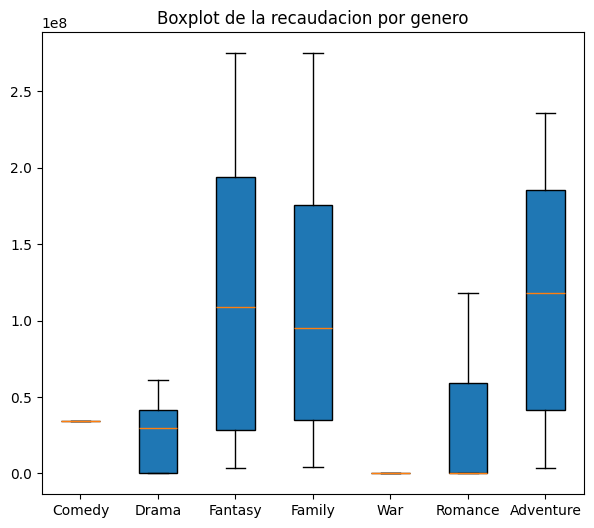

In [ ]:
#boxplot usando el dicionario de generos_recaudado
labels, data = generos_recaudado.keys(), generos_recaudado.values()

print(labels, data)
plt.figure(figsize=(7, 6))
plt.title('Boxplot de la recaudacion (en cientos de millones) por genero')
plt.boxplot(data,showfliers=False, patch_artist=True) #los fliers son datos que presentan la información en yenes, en lugar de dolares
#plt.title('Boxplot de la recaudacion por genero')
plt.xticks(range(1, len(labels) + 1), labels)
plt.show()

# Presupuesto usado por género

In [58]:
generos_presupuesto = {}
for i in range(len(generos_limpios)):
    generos_presupuesto[generos_limpios[i]] = []


# Recorremos el dataframe y llenamos el diccionario con los generos y su presupuesto
for i in range(len(df)):
    for j in range(1, 4):
        if str(df['Genre ' + str(j)][i]) != 'nan' and str(df['Genre ' + str(j)][i]) != 'Animation':
            temp = str(df['Budget'][i])
            temp = temp.replace('$', '')
            generos_presupuesto[str(df['Genre ' + str(j)][i])].append(float(temp))

print(generos_presupuesto)

#remover dato anomalo en Drama
generos_presupuesto['Drama'].remove(1150000000.0,) #Este dato esta en yenes mientras que el resto de información sobre el presupuesto esta en dolares

{'Comedy': [9200000.0], 'Drama': [1150000000.0, 49300000.0, 30000000.0, 22000000.0, 5000000.0, 2500000.0, 7000000.0, 3700000.0], 'Fantasy': [49300000.0, 23000000.0, 34000000.0, 22000000.0, 19000000.0, 3700000.0, 23500000.0, 24000000.0, 3000000.0, 6900000.0, 12000000.0, 20000000.0, 1000000.0, 100000000.0], 'Family': [23000000.0, 34000000.0, 19000000.0, 20500000.0, 7000000.0, 3700000.0, 6900000.0, 9200000.0], 'War': [3700000.0], 'Romance': [30000000.0, 5000000.0, 2500000.0], 'Adventure': [22000000.0, 23500000.0, 24000000.0, 3000000.0, 12000000.0, 20000000.0, 1000000.0, 100000000.0]}


dict_keys(['Comedy', 'Drama', 'Fantasy', 'Family', 'War', 'Romance', 'Adventure']) dict_values([[9200000.0], [49300000.0, 30000000.0, 22000000.0, 5000000.0, 2500000.0, 7000000.0, 3700000.0], [49300000.0, 23000000.0, 34000000.0, 22000000.0, 19000000.0, 3700000.0, 23500000.0, 24000000.0, 3000000.0, 6900000.0, 12000000.0, 20000000.0, 1000000.0, 100000000.0], [23000000.0, 34000000.0, 19000000.0, 20500000.0, 7000000.0, 3700000.0, 6900000.0, 9200000.0], [3700000.0], [30000000.0, 5000000.0, 2500000.0], [22000000.0, 23500000.0, 24000000.0, 3000000.0, 12000000.0, 20000000.0, 1000000.0, 100000000.0]])


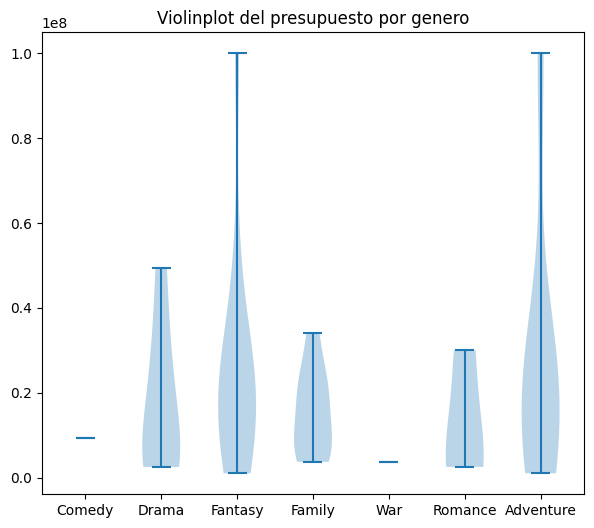

In [60]:
labels,data = generos_presupuesto.keys(), generos_presupuesto.values()

print(labels, data)
plt.figure(figsize=(7, 6))
plt.title('Violinplot del presupuesto por genero')
plt.violinplot(data)
#plt.title('Boxplot de la recaudacion por genero')
plt.xticks(range(1, len(labels) + 1), labels)
plt.show()